# Лабораторная работа №2
Егорова Варвара Александровна, P3323, 408575

## Задание
Используя Python-библиотеку Skfuzzy построить нечёткую базу знаний для задачи настройки аудиосистемы (мощность колонок, их количество, размер помещения, назначение установки и т.д.), произвести нечеткий вывод для конкретных значений.

Этапы выполнения работы:
1. Определить входные и выходные лингвистические переменные (общее количество лингвистических переменных должно быть не менее 3).
2. Задать функции принадлежности для нечетких подмножеств, определенных на значениях выбранных лингвистических переменных (не менее трех значений для каждой лингвистической переменной).
3. Определить нечеткие правила, описывающие работу рассматриваемой системы (не менее четырех правил, при
этом нечёткая база знаний должна быть полной).
4. Промоделировать работу нечеткой системы (не менее 5 прогонов с разными входными данными, заданными случайным образом).

Содержание отчета:
1. Описание предметной области, в том числе описание входных данных и выходных переменных, в чем они измеряются и т.д.
2. Нечеткие правила, описывающие работу системы.
3. Графики функций принадлежности для нечетких подмножеств, определенных на значениях выбранных лингвистических переменных.
4. Результаты нечёткого вывода (не мене пяти прогонов).


In [ ]:
! pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

space_size = ctrl.Antecedent(np.arange(1, 200_000, 1), 'space_size')
volume = ctrl.Antecedent(np.arange(60, 111, 1), 'volume')
listeners = ctrl.Antecedent(np.arange(1, 100_000, 1), 'listeners')

power = ctrl.Consequent(np.arange(10, 4000, 1), 'power')

space_size['small'] = fuzz.trimf(space_size.universe, [1, 1, 300])
space_size['medium'] = fuzz.trimf(space_size.universe, [200, 2000, 15000])
space_size['large'] = fuzz.trimf(space_size.universe, [10000, 30000, 80000])
space_size['huge'] = fuzz.trimf(space_size.universe, [50000, 200000, 200000])

volume['speech'] = fuzz.trimf(volume.universe, [60, 60, 70])
volume['music'] = fuzz.trimf(volume.universe, [65, 80, 90])
volume['loud_music'] = fuzz.trimf(volume.universe, [85, 95, 105])
volume['concert'] = fuzz.trimf(volume.universe, [100, 110, 110])


listeners['few'] = fuzz.trimf(listeners.universe, [1, 1, 100])
listeners['medium'] = fuzz.trimf(listeners.universe, [50, 1000, 5000])
listeners['many'] = fuzz.trimf(listeners.universe, [3000, 20000, 60000])
listeners['crowd'] = fuzz.trimf(listeners.universe, [50000, 100000, 100000])

power['low'] = fuzz.trimf(power.universe, [10, 10, 500])
power['medium'] = fuzz.trimf(power.universe, [300, 1000, 2000])
power['high'] = fuzz.trimf(power.universe, [1500, 3000, 4000])
power['extreme'] = fuzz.trimf(power.universe, [3000, 4000, 4000])



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


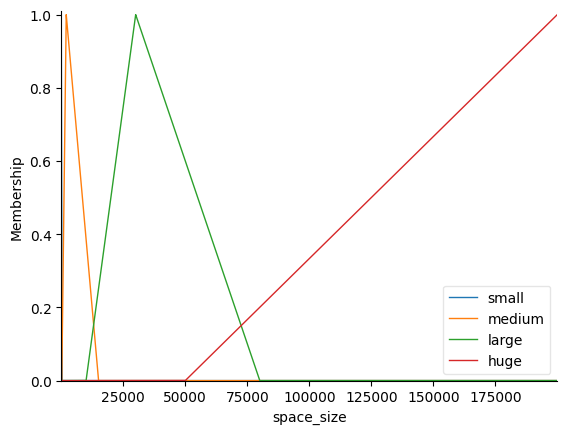

In [ ]:
space_size.view()

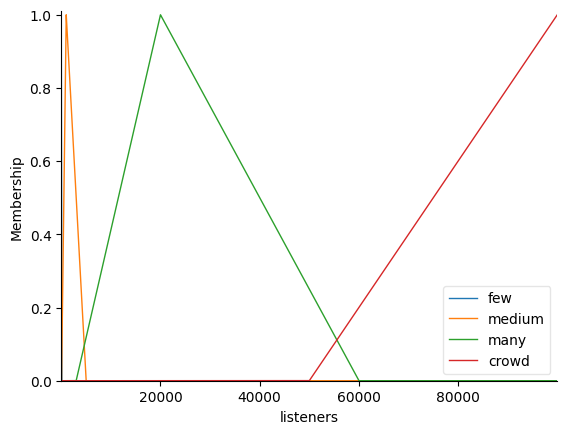

In [ ]:
listeners.view()

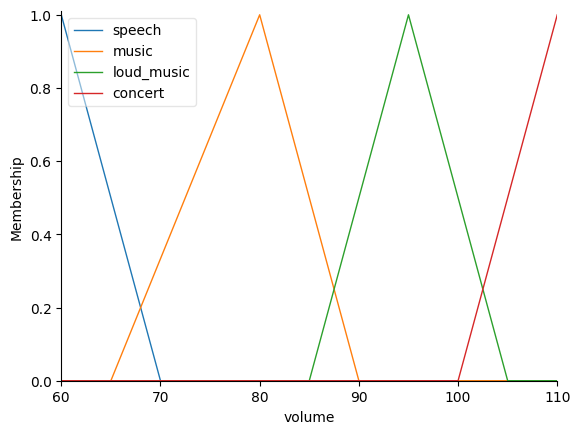

In [ ]:
volume.view()

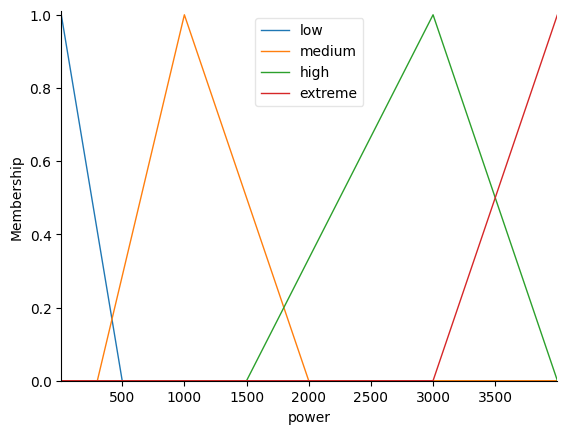

In [ ]:
power.view()

In [ ]:
rule1 = ctrl.Rule(space_size['small'], power['low'])
rule2 = ctrl.Rule(space_size['medium'], power['medium'])
rule3 = ctrl.Rule(space_size['large'], power['high'])
rule4 = ctrl.Rule(space_size['huge'], power['extreme'])
rule5 = ctrl.Rule(listeners['few'], power['low'])
rule6 = ctrl.Rule(listeners['medium'], power['medium'])
rule7 = ctrl.Rule(listeners['many'], power['high'])
rule8 = ctrl.Rule(listeners['crowd'], power['extreme'])
rule9  = ctrl.Rule(volume['speech'], power['low'])
rule10 = ctrl.Rule(volume['music'], power['medium'])
rule11 = ctrl.Rule(volume['loud_music'], power['high'])
rule12 = ctrl.Rule(volume['concert'], power['extreme'])
rule13 = ctrl.Rule(space_size['small'] & volume['concert'], power['high'])
rule14 = ctrl.Rule(space_size['medium'] & volume['concert'], power['high'])
rule15 = ctrl.Rule(space_size['large'] & volume['concert'], power['extreme'])
rule16 = ctrl.Rule(space_size['large'] & listeners['many'], power['high'])
rule17 = ctrl.Rule(space_size['large'] & listeners['crowd'], power['extreme'])
rule18 = ctrl.Rule(volume['loud_music'] & listeners['many'], power['high'])
rule19 = ctrl.Rule(volume['concert'] & listeners['many'], power['extreme'])

In [ ]:
# audio_ctrl = ctrl.ControlSystem([
#     rule1, rule2, rule3, rule4, rule5,
#     rule6, rule7, rule8, rule9, rule10, rule11, rule12
# ])

audio_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4,
    rule5, rule6, rule7, rule8,
    rule9, rule10, rule11, rule12,
    rule13, rule14, rule15,
    rule16, rule17, rule18, rule19
])

In [ ]:
audio_sim = ctrl.ControlSystemSimulation(audio_ctrl)

## Эксперименты

In [ ]:
audio_sim.input['space_size'] = 120
audio_sim.input['volume'] = 65
audio_sim.input['listeners'] = 40

audio_sim.compute()
print("Simulation 1 power:", audio_sim.output['power'], "w")

Simulation 1 power: 191.51734738691218 w


In [ ]:
audio_sim.input['space_size'] = 2500
audio_sim.input['volume'] = 80
audio_sim.input['listeners'] = 700

audio_sim.compute()
print("Simulation 2 power:", audio_sim.output['power'], "w")

Simulation 2 power: 1099.9999999999986 w


In [ ]:
audio_sim.input['space_size'] = 15000
audio_sim.input['volume'] = 95
audio_sim.input['listeners'] = 5000

audio_sim.compute()
print("Simulation 3 power:", audio_sim.output['power'])

Simulation 3 power: 2833.3328669331468


In [ ]:
audio_sim.input['space_size'] = 40000
audio_sim.input['volume'] = 105
audio_sim.input['listeners'] = 20000

audio_sim.compute()
print("Simulation 4 power:", audio_sim.output['power'])

Simulation 4 power: 2923.851279253061


In [ ]:
audio_sim.input['space_size'] = 120000
audio_sim.input['volume'] = 100
audio_sim.input['listeners'] = 70000

audio_sim.compute()
print("Simulation 5 power:", audio_sim.output['power'])

Simulation 5 power: 2913.179573138013


In [ ]:
audio_sim.input['space_size'] = 60000
audio_sim.input['volume'] = 65
audio_sim.input['listeners'] = 30000

audio_sim.compute()
print("Lecture in large hall:", audio_sim.output['power'])

Lecture in large hall: 2471.66007780999


In [ ]:
audio_sim.input['space_size'] = 250
audio_sim.input['volume'] = 75
audio_sim.input['listeners'] = 60

audio_sim.compute()
print("Cafe background music:", audio_sim.output['power'])

Cafe background music: 963.1766276435967


In [ ]:
audio_sim.input['space_size'] = 5000
audio_sim.input['volume'] = 95
audio_sim.input['listeners'] = 2000

audio_sim.compute()
print("Night club:", audio_sim.output['power'])

Night club: 2165.884415423144


In [ ]:
audio_sim.input['space_size'] = 150000
audio_sim.input['volume'] = 110
audio_sim.input['listeners'] = 80000

audio_sim.compute()
print("Open-air concert:", audio_sim.output['power'])

Open-air concert: 3666.000000000002


In [ ]:
audio_sim.input['space_size'] = 150
audio_sim.input['volume'] = 100
audio_sim.input['listeners'] = 120

audio_sim.compute()
print("House party overload:", audio_sim.output['power'])

House party overload: 2288.3324816778154
